## Simulations

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
def extract_values(file_path):
    """
    Parses a results file to extract values for each method.

    Assumes lines are formatted as: `[ignored] [method_name] [v1,v2,...]`.

    Args:
        file_path (str): The path to the input results file.

    Returns:
        Dict[str, List[float]]: A dictionary mapping method names (e.g., 'GEE')
        to a list of their corresponding floating-point metric values.
    """
    values = {'GEE': [], 'GNN': [], 'GG': [], 'GG2': []}

    with open(file_path, 'r') as file:
        lines = file.readlines()

    for line in lines:
        if line.strip() and not line.startswith('r_value'):
            parts = line.strip().split()
            method = parts[1]
            ari_values = list(map(float, parts[2].split(',')))

            values[method].extend(ari_values)

    return values

def mean_stderr(x: np.ndarray, block: int):
    """
    Computes mean and standard error for non-overlapping data blocks.
    
    Args:
        x (np.ndarray): A 1D array of data points.
        block_size (int): The size of each block to average over.

    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing:
            - An array of the means calculated for each block.
            - An array of the standard errors of the mean for each block.

    """
    x = np.asarray(x)[: (len(x) // block) * block]      
    x = x.reshape(-1, block)                           
    mean   = x.mean(axis=1)
    stderr = x.std(axis=1, ddof=1) / np.sqrt(block)
    return mean, stderr

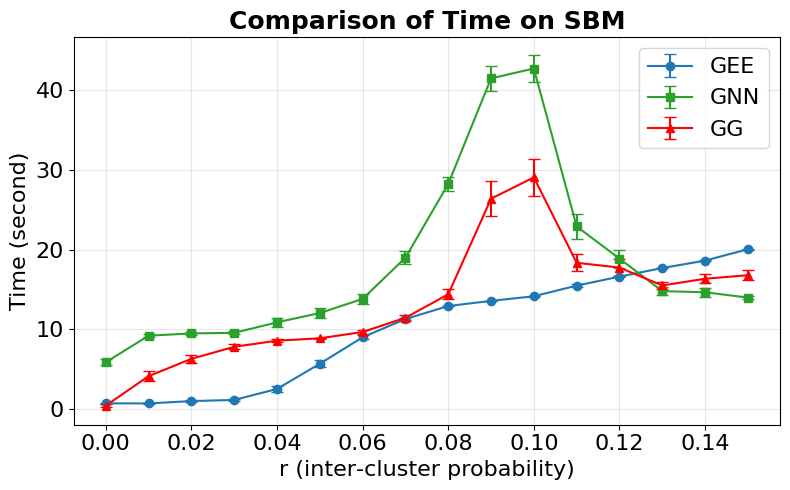

In [8]:
plt.rcParams.update({
    "figure.titlesize": 18,     
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16
})
flag = "SBM"
content = "time"
File   = Path(f"results/{flag}/{content}_{flag}_unbal.txt")
fig_path = f"figures/{flag}/{content}_unbal.png"
BLOCK  =  50                  
r_vals =  np.arange(0, 0.155, 0.01) if flag == "SBM" else np.arange(0, 0.301, 0.02) 
title = "ARI" if content == "ari" else "Time"
ylabel = "ARI (Adjusted Rand Index)" if content == "ari" else "Time (second)"

methods = ["GEE", "GNN", "GG"]
markers = dict(GEE="o", GNN="s", GG="^")
colors  = dict(GEE="#1f77b4", GNN="#2ca02c", GG="red")

# ---------------- Plot ----------------
vals = extract_values(File)                       
plt.figure(figsize=(8, 5))
for m in methods:
    mean, err = mean_stderr(vals[m], BLOCK)
    plt.errorbar(r_vals, mean, yerr=err,
                    fmt=f'-{markers[m]}', color=colors[m],
                    capsize=4, label=m)

plt.xlabel("r (inter‑cluster probability)")
plt.ylabel(ylabel)
plt.title(f"Comparison of {title} on {flag}", fontweight="bold")
plt.grid(alpha=.3)
plt.legend()
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

## Real data

In [1]:
from rich.table import Table
from io import StringIO
from rich.console import Console
def extract_values_realdata(file_path):
    """
    Parses a results file to compute mean and standard error per dataset.

    Args:
        file_path (str): The path to the input results file.

    Returns:
        Dict[str, Dict[str, Tuple[float, float]]]: A nested dictionary with the
        structure: `{dataset: {method: (mean, standard_error)}}`.
    """

    values = {}

    with open(file_path, 'r') as file:
        lines = file.readlines()

    for line in lines:
        if line.strip() and not line.startswith('r_value'):
            parts = line.strip().split()
            dataset = parts[0]
            method = parts[1]
            acc_values = list(map(float, parts[2].split(',')))
            if dataset not in values:
                values[dataset] = {}
            values[dataset][method] = (np.mean(acc_values),  np.std(acc_values, ddof=1)/np.sqrt(len(acc_values)) )

    return values

#### ARI Tables

In [4]:
File   = Path(f"results/real_data/ari.txt")
values = extract_values_realdata(File)

datasets = sorted(values.keys())
methods = ["GEE", "GNN", "GG"]
no_gee       = [m for m in methods if m != "GEE"] 

        
console = Console(record=True, width=100)
table = Table(show_lines=True)

table.add_column("Dataset")
for method in methods:
    table.add_column(method)

for ds in values:
    row = [ds]

    best_method = max(methods, key=lambda m: values[ds][m][0])

    for m in methods:
        mean, std = values[ds][m]
        content = f"{mean:.3f} ± {std:.3f}"
        if m == best_method: 
            content = f"[green]{content}[/green]"   
        row.append(content)
    
    table.add_row(*row)

console.print(table)

┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Dataset      ┃ GEE           ┃ GNN           ┃ GG            ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ACM          │ 0.033 ± 0.003 │ 0.034 ± 0.003 │ 0.059 ± 0.003 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ BAT          │ 0.043 ± 0.003 │ 0.060 ± 0.003 │ 0.085 ± 0.007 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ DBLP         │ 0.018 ± 0.001 │ 0.009 ± 0.001 │ 0.022 ± 0.001 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ EAT          │ 0.017 ± 0.001 │ 0.023 ± 0.002 │ 0.044 ± 0.005 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ UAT          │ 0.090 ± 0.001 │ 0.126 ± 0.002 │ 0.140 ± 0.003 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ Wiki         │ 0.116 ± 0.002 │ 0.106 ± 0.003 │ 0.124 ± 0.002 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ email        │ 0.436 ± 0.005 │ 0.340 ± 0.003 │ 0.537 ± 0.002 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ Gene         │ 0.008 ± 0.002 │ 0.008 ± 0.001 │ 0.011 ± 0.002 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ IIP          │ 0.061 ± 0.006 │ 0.099 ± 0.005 │ 0.126 ± 0.005 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ lastfm       │ 0.341 ± 0.004 │ 0.274 ± 0.009 │ 0.409 ± 0.004 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ polblogs     │ 0.812 ± 0.001 │ 0.745 ± 0.003 │ 0.821 ± 0.003 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ TerroristRel │ 0.062 ± 0.008 │ 0.075 ± 0.005 │ 0.078 ± 0.009 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ KarateClub   │ 0.449 ± 0.014 │ 0.725 ± 0.011 │ 0.726 ± 0.013 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ Chameleon    │ 0.045 ± 0.002 │ 0.056 ± 0.002 │ 0.060 ± 0.002 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ Cora         │ 0.137 ± 0.004 │ 0.111 ± 0.004 │ 0.166 ± 0.004 │
├──────────────┼───────────────┼───────────────┼───────────────┤
│ Citeseer     │ 0.046 ± 0.003 │ 0.035 ± 0.002 │ 0.056 ± 0.003 │
└──────────────┴───────────────┴───────────────┴───────────────┘

#### Time Tables

In [5]:
File   = Path(f"results/real_data/time.txt")
values = extract_values_realdata(File)

datasets = sorted(values.keys())
methods = ["GEE", "GNN", "GG"]
no_gee       = [m for m in methods if m != "GEE"] 

        
console = Console(record=True, width=100)
table = Table(show_lines=True)

table.add_column("Dataset")
for method in methods:
    table.add_column(method)

for ds in values:
    row = [ds]

    second_smallest_method = min(
        no_gee,
        key=lambda m: values[ds][m][0]       
    )


    for m in methods:
        mean, std = values[ds][m]
        content = f"{mean:.1f} ± {std:.1f}"
        if m == second_smallest_method:
            content = f"[green]{content}[/green]"   
        row.append(content)
    
    table.add_row(*row)

console.print(table)


┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Dataset      ┃ GEE        ┃ GNN          ┃ GG           ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ ACM          │ 5.8 ± 0.0  │ 54.0 ± 2.9   │ 47.8 ± 2.8   │
├──────────────┼────────────┼──────────────┼──────────────┤
│ BAT          │ 0.7 ± 0.0  │ 2.1 ± 0.0    │ 2.1 ± 0.0    │
├──────────────┼────────────┼──────────────┼──────────────┤
│ DBLP         │ 2.6 ± 0.0  │ 85.9 ± 5.2   │ 70.3 ± 3.2   │
├──────────────┼────────────┼──────────────┼──────────────┤
│ EAT          │ 2.6 ± 0.0  │ 4.6 ± 0.1    │ 4.5 ± 0.1    │
├──────────────┼────────────┼──────────────┼──────────────┤
│ UAT          │ 5.9 ± 0.0  │ 12.0 ± 0.2   │ 12.4 ± 0.3   │
├──────────────┼────────────┼──────────────┼──────────────┤
│ Wiki         │ 7.1 ± 0.0  │ 104.6 ± 5.1  │ 65.1 ± 3.7   │
├──────────────┼────────────┼──────────────┼──────────────┤
│ email        │ 8.3 ± 0.0  │ 29.4 ± 0.4   │ 28.2 ± 0.3   │
├──────────────┼────────────┼──────────────┼──────────────┤
│ Gene         │ 1.3 ± 0.0  │ 8.4 ± 0.3    │ 7.9 ± 0.1    │
├──────────────┼────────────┼──────────────┼──────────────┤
│ IIP          │ 0.6 ± 0.0  │ 2.8 ± 0.1    │ 2.9 ± 0.1    │
├──────────────┼────────────┼──────────────┼──────────────┤
│ lastfm       │ 14.2 ± 0.1 │ 779.6 ± 48.1 │ 474.1 ± 29.9 │
├──────────────┼────────────┼──────────────┼──────────────┤
│ polblogs     │ 6.6 ± 0.1  │ 17.5 ± 1.0   │ 10.4 ± 0.1   │
├──────────────┼────────────┼──────────────┼──────────────┤
│ TerroristRel │ 2.5 ± 0.1  │ 7.9 ± 0.2    │ 7.8 ± 0.2    │
├──────────────┼────────────┼──────────────┼──────────────┤
│ KarateClub   │ 0.3 ± 0.0  │ 1.8 ± 0.0    │ 1.8 ± 0.0    │
├──────────────┼────────────┼──────────────┼──────────────┤
│ Chameleon    │ 13.0 ± 0.1 │ 44.6 ± 2.1   │ 31.3 ± 1.0   │
├──────────────┼────────────┼──────────────┼──────────────┤
│ Cora         │ 3.4 ± 0.0  │ 80.6 ± 2.5   │ 59.2 ± 3.7   │
├──────────────┼────────────┼──────────────┼──────────────┤
│ Citeseer     │ 3.2 ± 0.0  │ 93.7 ± 3.7   │ 63.5 ± 3.0   │
└──────────────┴────────────┴──────────────┴──────────────┘

### Plot error bars

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd

# # Data from the table (highlighted yellow rows with mean values)
# datasets = ["Cora", "Citeseer", "ACM", "Chameleon", "EAT", "Industry"]
# # GEE_values = [0.1251, 0.05, 0.0311, 0.0468, 0.0151, 0.0773]
# # GNN_values = [0.0985, 0.0364, 0.0330, 0.0531, 0.0202, 0.0897]
# # GG_values = [0.1553, 0.0602, 0.0604, 0.0632, 0.0409, 0.1180]

# GEE_values = [4.109, 4.056, 4.631, 11.261, 2.058, 0.427]
# GNN_values = [62.323, 66.978, 45.343, 32.697, 1.863, 1.224]
# GG_values = [41.636, 50.622, 44.634, 19.807, 1.515, 1.185]

# # Create a DataFrame
# df = pd.DataFrame({
#     "Dataset": datasets,
#     "GEE": GEE_values,
#     "GNN": GNN_values,
#     "GG": GG_values
# })

# # Plot grouped bar chart
# fig, ax = plt.subplots(figsize=(10, 6))
# bar_width = 0.25
# index = np.arange(len(df))

# bars1 = ax.bar(index, df["GEE"], bar_width, label="GEE")
# bars2 = ax.bar(index + bar_width, df["GNN"], bar_width, label="GNN")
# bars3 = ax.bar(index + 2 * bar_width, df["GG"], bar_width, label="GG")

# # ax.set_xlabel("Dataset")
# # ax.set_ylabel("ARI Score")
# # ax.set_title("Performance Comparison on Real data")
# # ax.set_xticks(index + bar_width)
# # ax.set_xticklabels(df["Dataset"])
# # ax.legend()

# ax.set_xlabel("Dataset")
# ax.set_ylabel("Running Time (s)")
# ax.set_title("Running Time Comparison on Real data")
# ax.set_xticks(index + bar_width)
# ax.set_xticklabels(df["Dataset"])
# ax.legend()


# plt.savefig("figures/real_data_t.png", dpi=300, bbox_inches='tight')

# plt.show()